## Rainfields rainfall Product

Among the different rainfall products generated by Rainfields, three are available on the NCI Gadi. Two of those rainfall products are :


<b><u> 1) prcp-crate (gauge-calibrated rainfall product) </b></u>

        Time resolution: 5 minutes
        
        Description: This product is derived from Rainfields radar data and then bias-corrected using real-time rain gauge measurements.
        
        Method: A Kalman filter is used to adjust the radar-estimated rainfall rates so they better match the gauge observations.


<b><u> 2) prcp-m15 (gauge-merged rainfall product) <b></u>

        Time resolution: 15 minutes
        
        Description: This product is also based on Rainfields radar data, but the radar rainfall fields are blended with real-time rain gauges to produce a     
        merged estimate.
        
        Method: A conditional merging technique is used to combine radar and gauge information.


Both products are available:

For individual radar domains, identified by a radar ID

e.g. 2 = Melbourne radar, 66 = Brisbane radar

As a national mosaic, which combines all radars, identified by the code 310.


### Individual radar domain

In [1]:
import os
import xarray as xr
import requests
import zipfile
import matplotlib.pyplot as plt
import numpy as np


In [2]:
!pip install cartopy

  Using cached cartopy-0.25.0-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (6.1 kB)
Using cached cartopy-0.25.0-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl (11.8 MB)


In [3]:
import cartopy.crs as ccrs

In [4]:
def download_file(url, local_filename):
    print(f"Downloading {url}...")
    response = requests.get(url, stream=True)
    response.raise_for_status()
    with open(local_filename, 'wb') as f:
        for chunk in response.iter_content(chunk_size=8192):
            f.write(chunk)
    print(f"Successfully downloaded {local_filename}")
    return local_filename

def extract_zip(zip_file, extract_dir):
    print(f"Extracting {zip_file} to {extract_dir}...")
    os.makedirs(extract_dir, exist_ok=True)
    with zipfile.ZipFile(zip_file, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)
    print("Extraction completed")
    return extract_dir


In [5]:
zip_file_url = "https://thredds.nci.org.au/thredds/fileServer/rq0/rainfields3/2/2019/prcp-crate/2_20191201.prcp-crate.zip"

# backup in case thredds server may not be available
# zip_file_url = "https://github.com/cvelascof/some_radar_data/raw/refs/heads/main/rainfields3/2/2019/prcp-crate/2_20191201.prcp-crate.zip"

local_zip_filename = "2_20191201.prcp-crate.zip"
extracted_dir = "./extracted_data"

download_file(zip_file_url,local_zip_filename)
extract_zip(local_zip_filename,extracted_dir)


Successfully downloaded 2_20191201.prcp-crate.zip
Extracting 2_20191201.prcp-crate.zip to ./extracted_data...
Extraction completed


'./extracted_data'

In [6]:
! ls extracted_data/2_2019*prcp-crate* | tail -n 10

extracted_data/2_20191201_230042.prcp-crate.nc
extracted_data/2_20191201_230642.prcp-crate.nc
extracted_data/2_20191201_231245.prcp-crate.nc
extracted_data/2_20191201_231842.prcp-crate.nc
extracted_data/2_20191201_232442.prcp-crate.nc
extracted_data/2_20191201_233045.prcp-crate.nc
extracted_data/2_20191201_233642.prcp-crate.nc
extracted_data/2_20191201_234245.prcp-crate.nc
extracted_data/2_20191201_234842.prcp-crate.nc
extracted_data/2_20191201_235445.prcp-crate.nc


In [7]:
da = xr.open_dataset('./extracted_data/2_20191201_054842.prcp-crate.nc')
da

<xarray.Dataset> Size: 2MB
Dimensions:     (y: 512, n2: 2, x: 512)
Coordinates:
  * y           (y) float64 4kB 127.8 127.2 126.8 126.2 ... -126.8 -127.2 -127.8
  * x           (x) float64 4kB -127.8 -127.2 -126.8 ... 126.8 127.2 127.8
Dimensions without coordinates: n2
Data variables:
    valid_time  datetime64[ns] 8B ...
    proj        int8 1B ...
    y_bounds    (y, n2) float64 8kB ...
    x_bounds    (x, n2) float64 8kB ...
    rain_rate   (y, x) float64 2MB ...
Attributes:
    Conventions:   CF-1.7
    title:         Radar derived rain rate
    institution:   Commonwealth of Australia, Bureau of Meteorology (ABN 92 6...
    licence:       http://www.bom.gov.au/other/copyright.shtml
    source:        rainfields 3.1.7 drs-rainfields 2019-04-29
    station_id:    2
    station_name:  Melb

In [8]:
### Additional function for plotting

class cmap_rf3(object):
    """Define color maps for RF3 rainfall products."""

    from matplotlib.colors import ListedColormap
    import matplotlib.pyplot as plt

    # RAINFALL
    rainfall_colors = np.array([(255, 255, 255),  # 0.0
                                (245, 245, 255),  # 0.2
                                (180, 180, 255),  # 0.5
                                (120, 120, 255),  # 1.5
                                (20,  20, 255),  # 2.5
                                (0, 216, 195),  # 4.0
                                (0, 150, 144),  # 6.0
                                (0, 102, 102),  # 10
                                (255, 255,   0),  # 15
                                (255, 200,   0),  # 20
                                (255, 150,   0),  # 30
                                (255, 100,   0),  # 40
                                (255,   0,   0),  # 50
                                (200,   0,   0),  # 60
                                (120,   0,   0),  # 75
                                (40,   0,   0)])  # > 100
    rainfall_colors = rainfall_colors/255.
    cm_rainfall = ListedColormap(rainfall_colors, 'rainfall')
    rainfall_levels = [0., 1.0, 2.0, 4, 6, 10, 15, 20,
                       30, 40, 50, 60, 80, 100, 150, 200, 300]
    rainfall_levels_hr = [0., 0.2, 0.5, 1.5, 2.5, 4, 5, 7, 10, 15,
                          20, 25, 30, 35, 40, 45, 50]
    rainfall_levels_10min = [0., 0.1, 0.2, 0.3, 0.4, 0.5, 1.0, 2.0, 3.0, 4.0,
                          5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 15.0]

# Make a Cartopy Projection Object from netcdf Proj info
def get_ccrs_from_proj(ds):
    if 'proj' in ds.variables:
        try:
            return ccrs.AlbersEqualArea(central_longitude=ds.proj.attrs['longitude_of_central_meridian'],
                            central_latitude=ds.proj.attrs['latitude_of_projection_origin'],
                            false_easting=ds.proj.attrs['false_easting'],
                            false_northing=ds.proj.attrs['false_northing'],
                            standard_parallels=ds.proj.attrs['standard_parallel'],
                            globe=None)
        except Exception as err:
            print(err)
            return ccrs.PlateCarree()


def transform_coords_from_km_to_m(ds):
    """Transform coords from km to m (if required)."""
    if ds is not None:
        if 'x' in ds.coords:
            if 'units' in ds.x.attrs:
                if ds.x.units == 'km':
                    ds['x'] = ds.x*1000.
                    ds.x.attrs.update({'units':'m'})
                    ds.x.attrs.update({'standard_name':'projection_x_coordinate'})
                    message = '; Original coords x transformed to m from km'
                    if 'history' in ds.attrs:
                        ds.attrs['history'] += message
                    else:
                        ds.attrs['history'] = message
                if ds.y.units == 'km':
                    ds['y'] = ds.y*1000.
                    ds.y.attrs.update({'units':'m'})
                    ds.y.attrs.update({'standard_name':'projection_y_coordinate'})
                    ds.attrs['history'] += '; Original coords y transformed to m from km'
    return ds

In [9]:
target_proj = get_ccrs_from_proj(da)
da_km = transform_coords_from_km_to_m(da)

/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


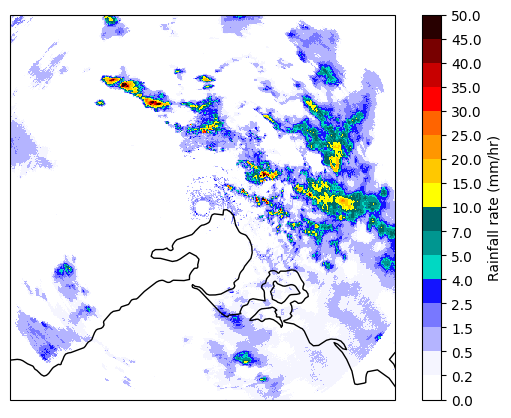

In [10]:
plt.figure(figsize=(7,5))
ax = plt.axes(projection=target_proj)
ax.set_xmargin(0)
ax.set_ymargin(0)
to_plot = da_km.rain_rate
to_plot.plot(ax=ax,
             vmin=0,
             cmap=cmap_rf3.cm_rainfall,
             levels=cmap_rf3.rainfall_levels_hr,
             cbar_kwargs={'ticks': cmap_rf3.rainfall_levels_hr,
                          'label': 'Rainfall rate (mm/hr)',
                          'extend': 'neither',
                          })
ax.coastlines('10m')

## Reading multiple radar files at once and plot the timeseries

In [11]:
def preprocess_radar(ds):
    ds = transform_coords_from_km_to_m(ds)
    ds = ds.assign_coords(valid_time=ds.valid_time).expand_dims('valid_time')
    if 'n2' in ds.dims:
        ds=ds.drop_dims('n2')
    return ds

In [12]:
ds_radar = xr.open_mfdataset('./extracted_data/2_20191201*.prcp-crate.nc',combine='by_coords',preprocess=preprocess_radar,parallel=True)
ds_radar

<xarray.Dataset> Size: 503MB
Dimensions:     (valid_time: 240, y: 512, x: 512)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 2kB 2019-12-01T00:00:42 ... 2019-...
  * y           (y) float64 4kB 1.278e+05 1.272e+05 ... -1.272e+05 -1.278e+05
  * x           (x) float64 4kB -1.278e+05 -1.272e+05 ... 1.272e+05 1.278e+05
Data variables:
    proj        (valid_time) int8 240B 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    rain_rate   (valid_time, y, x) float64 503MB dask.array<chunksize=(1, 512, 512), meta=np.ndarray>
Attributes:
    Conventions:   CF-1.7
    title:         Radar derived rain rate
    institution:   Commonwealth of Australia, Bureau of Meteorology (ABN 92 6...
    licence:       http://www.bom.gov.au/other/copyright.shtml
    source:        rainfields 3.1.7 drs-rainfields 2019-04-29
    station_id:    2
    station_name:  Melb
    history:       ; Original coords x transformed to m from km; Original coo...

# Calculate Mean of Rainfields along valid_time

In [13]:
# Calculate Mean of Rainfields
radar_mean = ds_radar.rain_rate.mean(['x','y'])
radar_mean

<xarray.DataArray 'rain_rate' (valid_time: 240)> Size: 2kB
dask.array<mean_agg-aggregate, shape=(240,), dtype=float64, chunksize=(1,), chunktype=numpy.ndarray>
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 2kB 2019-12-01T00:00:42 ... 2019-...

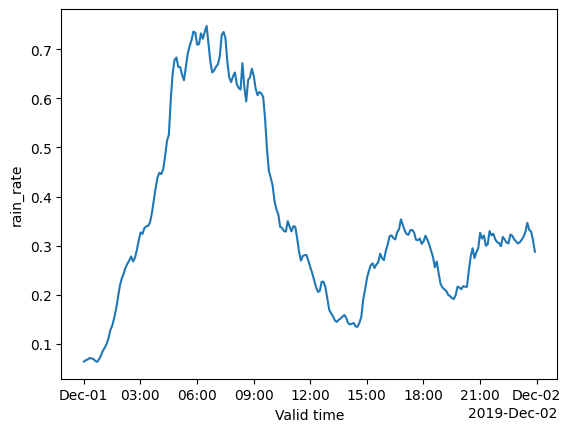

In [14]:
radar_mean.plot()

## find time step with maximum mean rainfall

In [15]:
max_valid_time = radar_mean.isel(valid_time=radar_mean.argmax().values).valid_time
max_valid_time

<xarray.DataArray 'valid_time' ()> Size: 8B
array('2019-12-01T06:30:45.000000000', dtype='datetime64[ns]')
Coordinates:
    valid_time  datetime64[ns] 8B 2019-12-01T06:30:45
Attributes:
    long_name:      Valid time
    standard_name:  time

## Reading national moasic calibrated radar data

In [16]:
zip_file_url = "https://thredds.nci.org.au/thredds/fileServer/rq0/rainfields3/310/2024/prcp-crate/310_20240101.prcp-crate.zip"
# backup in case thredds server may not be available
# zip_file_url = "https://github.com/cvelascof/some_radar_data/raw/refs/heads/main/rainfields3/310/2024/prcp-crate/310_20240101.prcp-crate.zip"
local_zip_filename = "310_20240101.prcp-crate.zip"

download_file(zip_file_url,local_zip_filename)
extract_zip(local_zip_filename,extracted_dir)

Successfully downloaded 310_20240101.prcp-crate.zip
Extracting 310_20240101.prcp-crate.zip to ./extracted_data...
Extraction completed


'./extracted_data'

In [17]:
! ls ./extracted_data/310*.nc | tail -n 10

./extracted_data/310_20240101_231000.prcp-crate.nc
./extracted_data/310_20240101_231500.prcp-crate.nc
./extracted_data/310_20240101_232000.prcp-crate.nc
./extracted_data/310_20240101_232500.prcp-crate.nc
./extracted_data/310_20240101_233000.prcp-crate.nc
./extracted_data/310_20240101_233500.prcp-crate.nc
./extracted_data/310_20240101_234000.prcp-crate.nc
./extracted_data/310_20240101_234500.prcp-crate.nc
./extracted_data/310_20240101_235000.prcp-crate.nc
./extracted_data/310_20240101_235500.prcp-crate.nc


In [18]:
da_national = xr.open_dataset('./extracted_data/310_20240101_080500.prcp-crate.nc')
da_national

<xarray.Dataset> Size: 40MB
Dimensions:     (y: 2050, n2: 2, x: 2450)
Coordinates:
  * y           (y) float64 16kB -1.001e+03 -1.003e+03 ... -5.097e+03 -5.099e+03
  * x           (x) float64 20kB -2.299e+03 -2.297e+03 ... 2.597e+03 2.599e+03
Dimensions without coordinates: n2
Data variables:
    valid_time  datetime64[ns] 8B ...
    proj        int8 1B ...
    y_bounds    (y, n2) float64 33kB ...
    x_bounds    (x, n2) float64 39kB ...
    rain_rate   (y, x) float64 40MB ...
Attributes:
    Conventions:         CF-1.7
    contributing_sites:  [  2   3   4   5   6   7   8  14  15  16  17  19  22...
    institution:         Commonwealth of Australia, Bureau of Meteorology (AB...
    licence:             http://www.bom.gov.au/other/copyright.shtml
    source:              rainfields 3.3.0 2023-11-21
    station_id:          310
    station_name:        Ausm310
    title:               Bias Corrected Rainfall Rate Mosaic

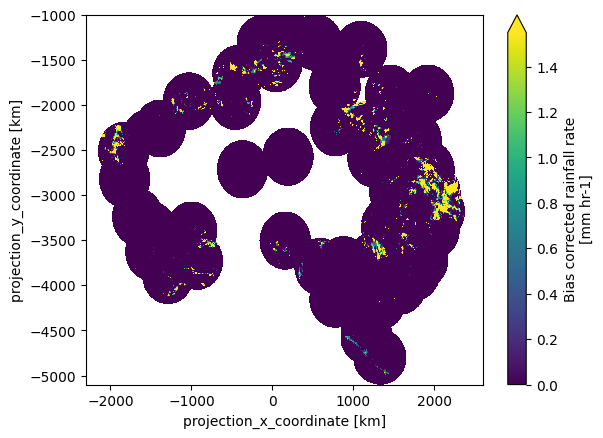

In [20]:
da_national.rain_rate.plot(robust=True)

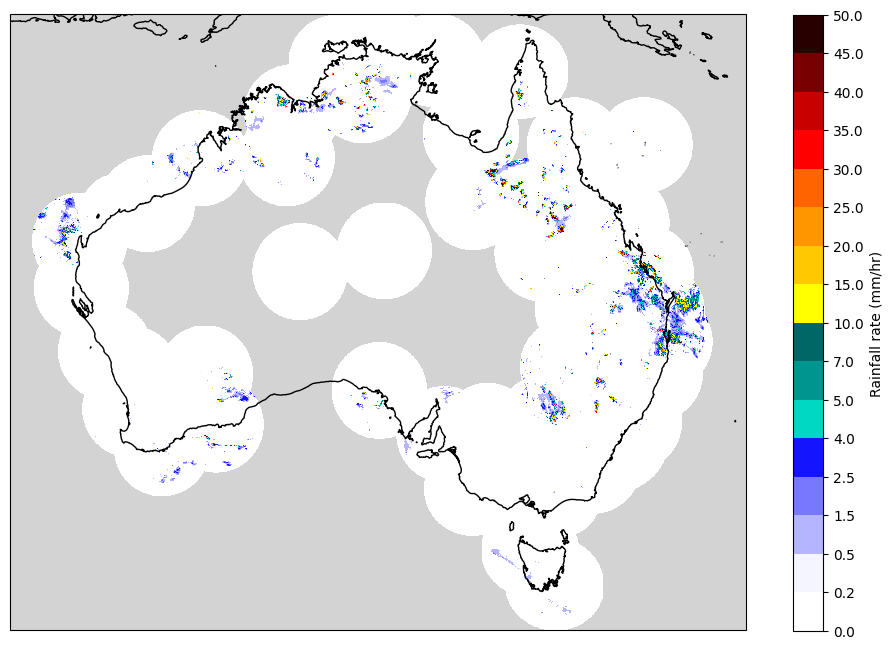

In [21]:
national_proj = get_ccrs_from_proj(da_national)
da_national_km  = transform_coords_from_km_to_m(da_national)


cmap = cmap_rf3.cm_rainfall.copy()
cmap.set_bad(color='lightgrey')

plt.figure(figsize=(12,8))
ax = plt.axes(projection=national_proj)
ax.set_xmargin(0)
ax.set_ymargin(0)
to_plot = da_national_km.rain_rate
to_plot.plot(ax=ax,
             vmin=0,
             cmap=cmap,
             levels=cmap_rf3.rainfall_levels_hr,
             cbar_kwargs={'ticks': cmap_rf3.rainfall_levels_hr,
                          'label': 'Rainfall rate (mm/hr)',
                          'extend': 'neither',
                          })
ax.coastlines('10m')

# prcp-m15 products

In [22]:
zip_file_url = "https://thredds.nci.org.au/thredds/fileServer/rq0/rainfields3/310/2024/prcp-m15/310_20240101.prcp-m15.zip"
local_zip_filename = "310_20240101.prcp-m15.zip"

download_file(zip_file_url,local_zip_filename)
extract_zip(local_zip_filename,extracted_dir)

Successfully downloaded 310_20240101.prcp-m15.zip
Extracting 310_20240101.prcp-m15.zip to ./extracted_data...
Extraction completed


'./extracted_data'

In [29]:
!ls ./extracted_data/310*prcp-m15.nc

./extracted_data/310_20240101_000000.prcp-m15.nc
./extracted_data/310_20240101_001500.prcp-m15.nc
./extracted_data/310_20240101_003000.prcp-m15.nc
./extracted_data/310_20240101_004500.prcp-m15.nc
./extracted_data/310_20240101_010000.prcp-m15.nc
./extracted_data/310_20240101_011500.prcp-m15.nc
./extracted_data/310_20240101_013000.prcp-m15.nc
./extracted_data/310_20240101_014500.prcp-m15.nc
./extracted_data/310_20240101_020000.prcp-m15.nc
./extracted_data/310_20240101_021500.prcp-m15.nc
./extracted_data/310_20240101_023000.prcp-m15.nc
./extracted_data/310_20240101_024500.prcp-m15.nc
./extracted_data/310_20240101_030000.prcp-m15.nc
./extracted_data/310_20240101_031500.prcp-m15.nc
./extracted_data/310_20240101_033000.prcp-m15.nc
./extracted_data/310_20240101_034500.prcp-m15.nc
./extracted_data/310_20240101_040000.prcp-m15.nc
./extracted_data/310_20240101_041500.prcp-m15.nc
./extracted_data/310_20240101_043000.prcp-m15.nc
./extracted_data/310_20240101_044500.prcp-m15.nc
./extracted_data/310

In [23]:
da_m15 = xr.open_dataset('./extracted_data/310_20240101_081500.prcp-m15.nc')
da_m15

<xarray.Dataset> Size: 40MB
Dimensions:        (y: 2050, n2: 2, x: 2450)
Coordinates:
  * y              (y) float64 16kB -1.001e+03 -1.003e+03 ... -5.099e+03
  * x              (x) float64 20kB -2.299e+03 -2.297e+03 ... 2.599e+03
Dimensions without coordinates: n2
Data variables:
    valid_time     datetime64[ns] 8B ...
    start_time     datetime64[ns] 8B ...
    proj           int8 1B ...
    y_bounds       (y, n2) float64 33kB ...
    x_bounds       (x, n2) float64 39kB ...
    precipitation  (y, x) float64 40MB ...
Attributes:
    Conventions:         CF-1.7
    contributing_sites:  [  2   3   4   5   6   7   8  14  15  16  17  19  22...
    institution:         Commonwealth of Australia, Bureau of Meteorology (AB...
    licence:             http://www.bom.gov.au/other/copyright.shtml
    source:              rainfields 3.3.0 2023-11-21
    station_id:          310
    station_name:        Ausm310
    title:               Merged Gauge/Radar Accumulation Mosaic (15 min)

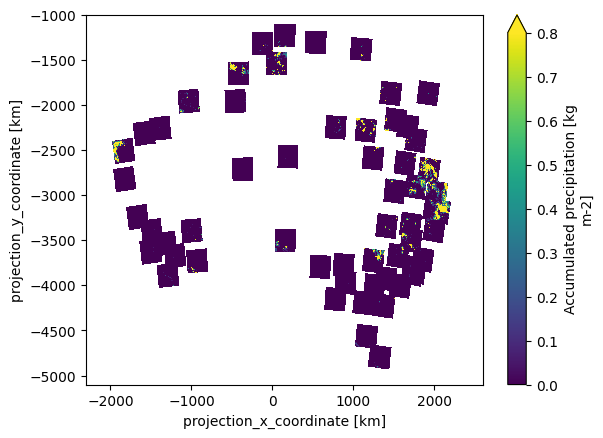

In [24]:
da_m15.precipitation.plot(robust=True)

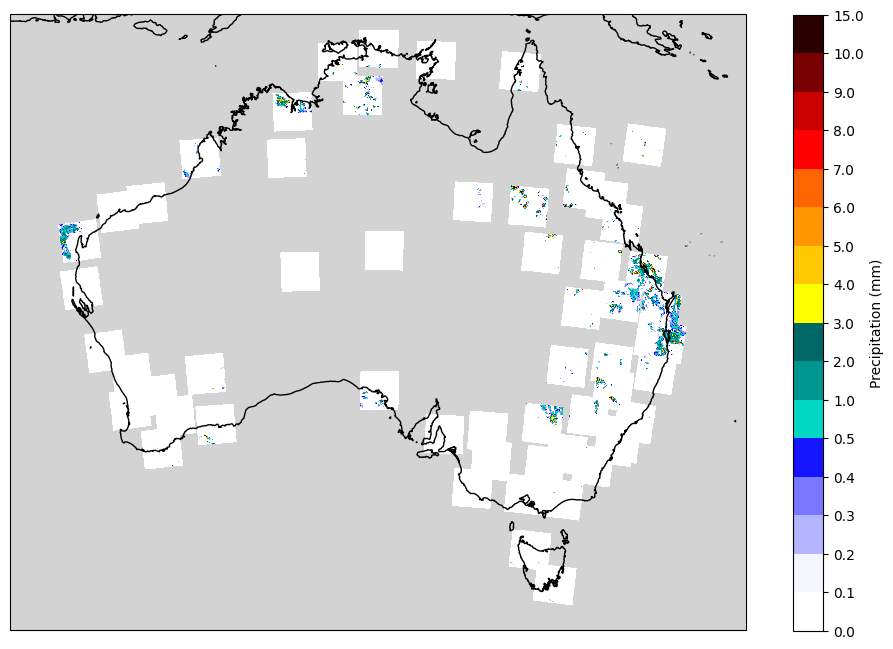

In [26]:
national_proj = get_ccrs_from_proj(da_m15)
da_m15_km  = transform_coords_from_km_to_m(da_m15)


cmap = cmap_rf3.cm_rainfall.copy()
cmap.set_bad(color='lightgrey')

plt.figure(figsize=(12,8))
ax = plt.axes(projection=national_proj)
ax.set_xmargin(0)
ax.set_ymargin(0)
to_plot = da_m15_km.precipitation
to_plot.plot(ax=ax,
             vmin=0,
             cmap=cmap,
             levels=cmap_rf3.rainfall_levels_10min,
             cbar_kwargs={'ticks': cmap_rf3.rainfall_levels_10min,
                          'label': 'Precipitation (mm)',
                          'extend': 'neither',
                          })
ax.coastlines('10m')

In [30]:
#OPEN multiple files

ds_radar_merged_all = xr.open_mfdataset('./extracted_data/310_20240101_*.prcp-m15.nc',combine='by_coords',preprocess=preprocess_radar,parallel=True)
ds_radar_merged_all

<xarray.Dataset> Size: 4GB
Dimensions:        (valid_time: 96, y: 2050, x: 2450)
Coordinates:
  * valid_time     (valid_time) datetime64[ns] 768B 2024-01-01 ... 2024-01-01...
  * y              (y) float64 16kB -1.001e+06 -1.003e+06 ... -5.099e+06
  * x              (x) float64 20kB -2.299e+06 -2.297e+06 ... 2.599e+06
Data variables:
    start_time     (valid_time) datetime64[ns] 768B 2023-12-31T23:45:00 ... 2...
    proj           (valid_time) int8 96B 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    precipitation  (valid_time, y, x) float64 4GB dask.array<chunksize=(1, 2050, 2450), meta=np.ndarray>
Attributes:
    Conventions:         CF-1.7
    contributing_sites:  [  2   3   4   5   6   7   8  14  15  16  17  19  22...
    institution:         Commonwealth of Australia, Bureau of Meteorology (AB...
    licence:             http://www.bom.gov.au/other/copyright.shtml
    source:              rainfields 3.3.0 2023-11-21
    station_id:          310
    station_name:        Ausm310
    title:               Merged Gauge/Radar Accumulation Mosaic (15 min)
    history:             ; Original coords x transformed to m from km; Origin...

In [31]:
# TOTAL DAILY RAINFALL
total_daily_precip = ds_radar_merged_all.precipitation.sum('valid_time',min_count=1)
total_daily_precip



<xarray.DataArray 'precipitation' (y: 2050, x: 2450)> Size: 40MB
dask.array<where, shape=(2050, 2450), dtype=float64, chunksize=(2050, 2450), chunktype=numpy.ndarray>
Coordinates:
  * y        (y) float64 16kB -1.001e+06 -1.003e+06 ... -5.097e+06 -5.099e+06
  * x        (x) float64 20kB -2.299e+06 -2.297e+06 ... 2.597e+06 2.599e+06

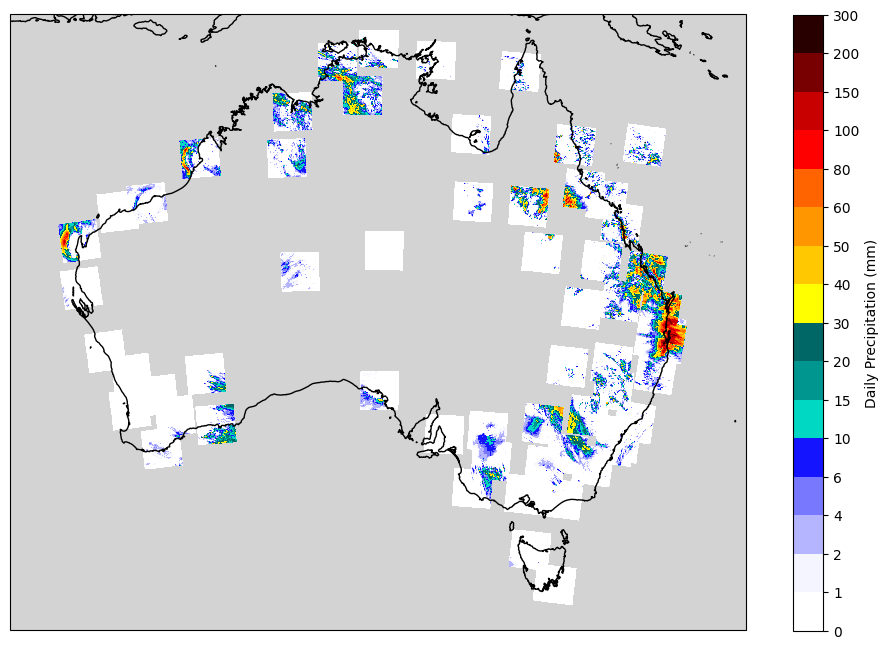

In [33]:
plt.figure(figsize=(12,8))
ax = plt.axes(projection=national_proj)
ax.set_xmargin(0)
ax.set_ymargin(0)
to_plot = total_daily_precip
to_plot.plot(ax=ax,
             vmin=0,
             cmap=cmap,
             levels=cmap_rf3.rainfall_levels,
             cbar_kwargs={'ticks': cmap_rf3.rainfall_levels,
                          'label': 'Daily Precipitation (mm)',
                          'extend': 'neither',
                          })
ax.coastlines('10m')